In [1]:
!pip install pandas seaborn scikit-learn

# Домашнее задание 3

1. Выбрать номинальное значение как целевую переменную
2. Провести разведочный анализ **включая** анализ зависимости между номинальными переменными (chi2)
3. Выбрать `best_features`
4. Сделать нормализацию данных (scaler, onehotencoding)
4. Обучить модель логистической регрессии
5. Вывести метрики качества, описать полученный результат (также вывести коэфициенты модели)

Школа считается Успешной, если ее средний балл превышает общий медианный балл по всей выборке.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('education_inequality_data.csv')

median_score = df['avg_test_score_percent'].median()

df['is_successful'] = (df['avg_test_score_percent'] > median_score).astype(int)

class_balance = df['is_successful'].value_counts(normalize=True) * 100

print(f"Медианный средний балл (порог успеха): {median_score:.2f}%")
print("\nБаланс классов 'is_successful'")
print(class_balance)

Y_target = df['is_successful']
X = df.drop(['id', 'school_name', 'avg_test_score_percent', 'is_successful'], axis=1)

Медианный средний балл (порог успеха): 69.90%

Баланс классов 'is_successful'
is_successful
0    50.0
1    50.0
Name: proportion, dtype: float64


### EDA


Тест Хи-квадрат (зависимость категориальных признаков от is_successful)
Признак state: P-value = 0.4058. Слабая/отсутствует зависимость.
Признак school_type: P-value = 0.4697. Слабая/отсутствует зависимость.
Признак grade_level: P-value = 0.7646. Слабая/отсутствует зависимость.


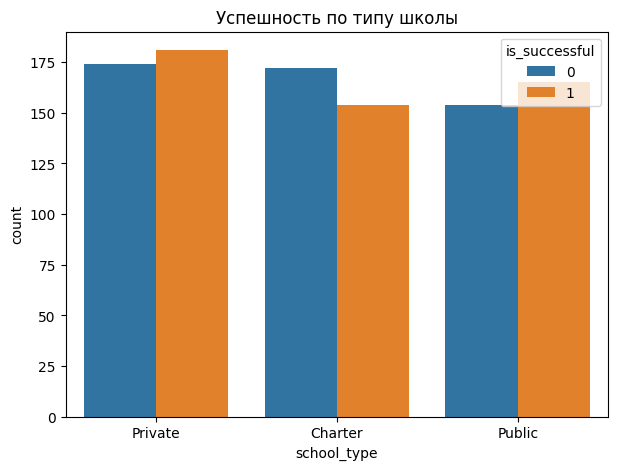

In [35]:
from scipy.stats import chi2_contingency

categorical_features = ['state', 'school_type', 'grade_level']

print("\nТест Хи-квадрат (зависимость категориальных признаков от is_successful)")

chi2_results = {}
for col in categorical_features:
    contingency_table = pd.crosstab(df[col], df['is_successful'])

    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    chi2_results[col] = {'Chi2': chi2, 'P-value': p_value}

    if p_value < 0.05:
        print(f"Признак {col}: P-value = {p_value:.4f}. Сильная зависимость от 'is_successful'.")
    else:
        print(f"Признак {col}: P-value = {p_value:.4f}. Слабая/отсутствует зависимость.")

plt.figure(figsize=(7, 5))
sns.countplot(x='school_type', hue='is_successful', data=df)
plt.title("Успешность по типу школы")
plt.show()

In [21]:
best_features = [
    'dropout_rate_percent',
    'percent_low_income',
    'internet_access_percent',
    'school_type',
    'grade_level'
]
X_best = df[best_features]

### Model

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

X_train, X_test, Y_train, Y_test = train_test_split(
    X_best,
    Y_target,
    test_size=0.2,
    random_state=42
)

numerical_best = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_best = X_train.select_dtypes(include='object').columns.tolist()

preprocessor_clf = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_best),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_best)
    ],
    remainder='passthrough'
)

X_train_processed = preprocessor_clf.fit_transform(X_train)
X_test_processed = preprocessor_clf.transform(X_test)

In [28]:
from sklearn.linear_model import LogisticRegression

model_logreg = LogisticRegression(random_state=42, solver='liblinear')
model_logreg.fit(X_train_processed, Y_train)

Y_pred_logreg = model_logreg.predict(X_test_processed)
Y_pred_proba_logreg = model_logreg.predict_proba(X_test_processed)[:, 1]

In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

accuracy = accuracy_score(Y_test, Y_pred_logreg)
precision = precision_score(Y_test, Y_pred_logreg)
recall = recall_score(Y_test, Y_pred_logreg)
f1 = f1_score(Y_test, Y_pred_logreg)
roc_auc = roc_auc_score(Y_test, Y_pred_proba_logreg)
conf_matrix = confusion_matrix(Y_test, Y_pred_logreg)

print("\nМетрики Логистической Регрессии (TEST)")
print(f"Accuracy (Точность):   {accuracy:.4f}")
print(f"Precision (Точность):  {precision:.4f}")
print(f"Recall (Полнота):      {recall:.4f}")
print(f"F1-Score:              {f1:.4f}")
print(f"ROC AUC Score:         {roc_auc:.4f}")

feature_names_logreg = (
    numerical_best +
    preprocessor_clf.named_transformers_['cat'].get_feature_names_out(categorical_best).tolist()
)

coef_df_logreg = pd.DataFrame({
    'feature': feature_names_logreg,
    'coefficient': model_logreg.coef_[0]
}).sort_values('coefficient', ascending=False)

print("\nКоэффициенты Модели")
print(coef_df_logreg)


Метрики Логистической Регрессии (TEST)
Accuracy (Точность):   0.5200
Precision (Точность):  0.5143
Recall (Полнота):      0.5455
F1-Score:              0.5294
ROC AUC Score:         0.5024

Коэффициенты Модели (Влияние на Успешность)
                   feature  coefficient
6       grade_level_Middle     0.191247
4       school_type_Public     0.140272
3      school_type_Private     0.118905
5         grade_level_High     0.094723
2  internet_access_percent     0.025490
0     dropout_rate_percent    -0.029831
1       percent_low_income    -0.050868


1. Accuracy = 0.5200. Модель правильно классифицирует 52% школ.
2. Precision = 0.5143. Из всех школ, которые модель предсказала как "Успешные", только 51.4% действительно успешны.
3. Recall = 0.5455. Модель находит 54.5% всех реальных "Успешных" школ.
4. F1-Score = 0.5294. Среднее гармоническое между Precision и Recall.
5. ROC AUC Score = 0.5024. Критически низкий. Модель почти не способна ранжировать "Успешные" школы выше "Неуспешных".
Метрики Accuracy, ROC AUC показывают, что модель Логистической Регрессии не работает. Результат ROC AUC означает, что модель работает случайным образом. Зависимость между данными не является линейной или логистической.

1. grade_level_Middle = 0.1912. Самый сильный положительный фактор. После стандартизации, принадлежность к "Средней ступени" значительно увеличивает вероятность успеха.
2. school_type_Public = 0.1403. Положительный.
3. school_type_Private = 0.1189. Положительный.
4. internet_access_percent = 0.0255. Слабый положительный вклад.
5. dropout_rate_percent = -0.0298. Слабый отрицательный вклад. Увеличение отсева немного снижает вероятность успеха.
6. percent_low_income = -0.0509. Самый сильный отрицательный фактор. Увеличение процента малообеспеченных учеников снижает вероятность успеха.

Несмотря на то, что модель в целом не работает, коэффициенты логистической регрессии логичны.

1. percent_low_income - самый сильный негативный фактор.
2. grade_level_Middle и school_type_Public, school_type_Private - самое сильные положительные факторы.

Коэффициенты очень малы, что говорит о том, что модель не смогла найти сильную, надежную связь.

/tmp/ipython-input-726540431.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


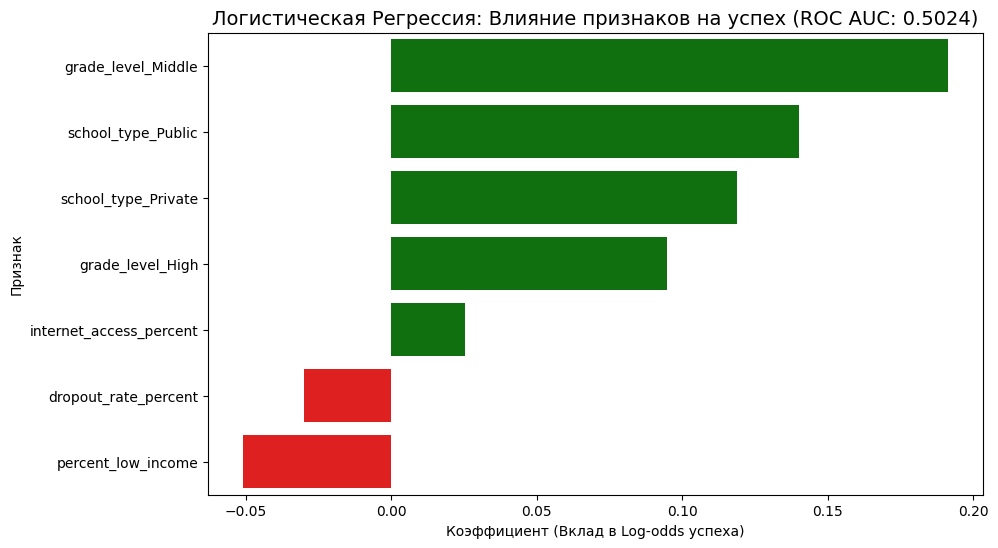

In [38]:
plt.figure(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in coef_df_logreg['coefficient']]
sns.barplot(
    x='coefficient',
    y='feature',
    data=coef_df_logreg,
    palette=colors
)

plt.title(f'Логистическая Регрессия: Влияние признаков на успех (ROC AUC: {roc_auc:.4f})', fontsize=14)
plt.xlabel('Коэффициент (Вклад в Log-odds успеха)')
plt.ylabel('Признак')
plt.show()